In [ ]:
board = [' '] * 9

def draw_board():
  print(f' {board[0]} | {board[1]} | {board[2]} ')
  print('---+---+---')
  print(f' {board[3]} | {board[4]} | {board[5]} ')
  print('---+---+---')
  print(f' {board[6]} | {board[7]} | {board[8]} ')

def computer_move():
  best_score = -float('inf')
  best_move = None
  for i in range(9):
    if board[i] == ' ':
      board[i] = 'X'
      score = minimax(board, False)
      board[i] = ' '
      if score > best_score:
        best_score = score
        best_move = i
  board[best_move] = 'X'

def minimax(board, is_maximizing):
  winner = check_winner()
  if winner == 'O':
    return -1
  elif winner == 'X':
    return 1
  elif ' ' not in board:
    return 0

  if is_maximizing:
    best_score = -float('inf')
    for i in range(9):
      if board[i] == ' ':
        board[i] = 'X'
        score = minimax(board, False)
        board[i] = ' '
        best_score = max(score, best_score)
    return best_score
  else:
    best_score = float('inf')
    for i in range(9):
      if board[i] == ' ':
        board[i] = 'O'
        score = minimax(board, True)
        board[i] = ' '
        best_score = min(score, best_score)
    return best_score

def player_move():
  move = input("Wprowadz numer (1-9): ")
  try:
    move = int(move) - 1
    if move in range(9) and board[move] == ' ':
      board[move] = 'O'
    else:
      print("------Bład!------ Prosze wybrac inny numer.")
      player_move()
  except ValueError:
    print("------Bład!------ Prosze wybrac numer od 1-9.")
    player_move()

def check_winner():
  winning_combinations = [
    [0, 1, 2], [3, 4, 5], [6, 7, 8],  # rows
    [0, 3, 6], [1, 4, 7], [2, 5, 8],  # columns
    [0, 4, 8], [2, 4, 6]  # diagonals
  ]
  for combination in winning_combinations:
    if board[combination[0]] == board[combination[1]] == board[combination[2]] and board[combination[0]] != ' ':
      return board[combination[0]]
  return None

def main():
  draw_board()
  while True:
    computer_move()
    draw_board()
    winner = check_winner()
    if winner:
      print("Przegrana")
      break
    elif ' ' not in board:
      print("Remis")
      break
    player_move()
    draw_board()
    winner = check_winner()
    if winner:
      print("Wygrana")
      break

main()


   |   |   
---+---+---
   |   |   
---+---+---
   |   |   
 X |   |   
---+---+---
   |   |   
---+---+---
   |   |   
 X |   |   
---+---+---
   | O |   
---+---+---
   |   |   
 X | X |   
---+---+---
   | O |   
---+---+---
   |   |   
 X | X | O 
---+---+---
   | O |   
---+---+---
   |   |   
 X | X | O 
---+---+---
   | O |   
---+---+---
 X |   |   
 X | X | O 
---+---+---
 O | O |   
---+---+---
 X |   |   
 X | X | O 
---+---+---
 O | O | X 
---+---+---
 X |   |   
------Bład!------ Prosze wybrac numer od 1-9.
------Bład!------ Prosze wybrac numer od 1-9.


KeyboardInterrupt: Interrupted by user

# Poda a-b

En la primera rama no tiene cómo descartar


Si en un nodo MAX $\{\alpha,\beta\}$
$$
\text{Si } V_i\ge\beta\quad\text{Poda }\beta    \\
\text{Si } V_i>\alpha\quad\text{Modifica }\alpha \\
\text{retorno }\alpha$$

Si en un nodo MIN $\{\alpha,\beta\}$
$$
\text{Si } V_i\le\alpha\quad\text{Poda }\alpha    \\
\text{Si } V_i<\beta\quad\text{Modifica }\beta \\
\text{retorno }\beta
$$


In [7]:
%pip install pygraphviz

  Using cached pygraphviz-1.14.tar.gz (106 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pygraphviz
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [94 lines of output]
      C:\Users\overd\AppData\Local\Temp\pip-build-env-9gi62fw_\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
      
              By 2026-Feb-18, you need to update your project and remove deprecated calls
              or your builds will no longer be supported.
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              **********************************************

In [ ]:

import networkx as nx
import matplotlib.pyplot as plt

grafo_ab = {
    'a': [('m', 7), ('n', 1)],
    'b': [('d', 3), ('e', 5)],
    'c': [('f', 5), ('g', 7), ('h', 4)],
    'f': [('i', 0), ('j', 5)],
    'i': [('k', 0), ('l', 1)],
    'g': [('m', 7), ('n', 1)],
}



def alpha_beta_pruning(graph, node, alpha, beta, maximizing_player, depth=0):
    if node not in graph or not graph[node]:  # Leaf node
        return node[1] if isinstance(node, tuple) else 0

    if maximizing_player:
        max_eval = -float('inf')
        for child, value in graph[node]:
            eval = alpha_beta_pruning(graph, child, alpha, beta, False, depth + 1)
            max_eval = max(max_eval, eval)
            alpha = max(alpha, eval)
            visualize_step(graph, node, alpha, beta, depth)
            if beta <= alpha:
                break  # Beta cut-off
        return max_eval
    else:
        min_eval = float('inf')
        for child, value in graph[node]:
            eval = alpha_beta_pruning(graph, child, alpha, beta, True, depth + 1)
            min_eval = min(min_eval, eval)
            beta = min(beta, eval)
            visualize_step(graph, node, alpha, beta, depth)
            if beta <= alpha:
                break  # Alpha cut-off
        return min_eval

def visualize_step(graph, current_node, alpha, beta, depth):
    plt.figure(figsize=(10, 8))
    G = nx.DiGraph()
    for parent, children in graph.items():
        for child, value in children:
            G.add_edge(parent, child, weight=value)

    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")  # Use graphviz layout for tree structure
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold")
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

    plt.title(f"Node: {current_node}, Alpha: {alpha}, Beta: {beta}, Depth: {depth}")
    plt.show()

# Run the alpha-beta pruning algorithm and visualize
alpha_beta_pruning(grafo_ab, 'a', -float('inf'), float('inf'), True)

En minimax ganó pues el 4

Poda:


1. Para podar primero tiene que evaluar toda la primera rama, no hay más formita
[-inf, inf]

[4]
[3],[4],[2]
[10][4][8],[3][7][8],[2][7][5]






=== EJEMPLOS DE USO ===

1. Triqui simple con etiquetas:


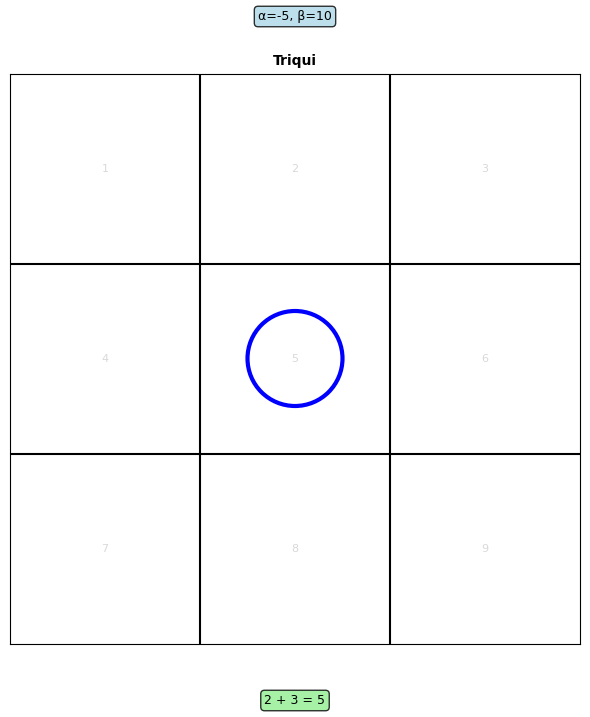


2. Generando árbol: Padre con O en posición 5
   Los hijos tendrán X en cada posición libre (EN UNA SOLA LÍNEA)


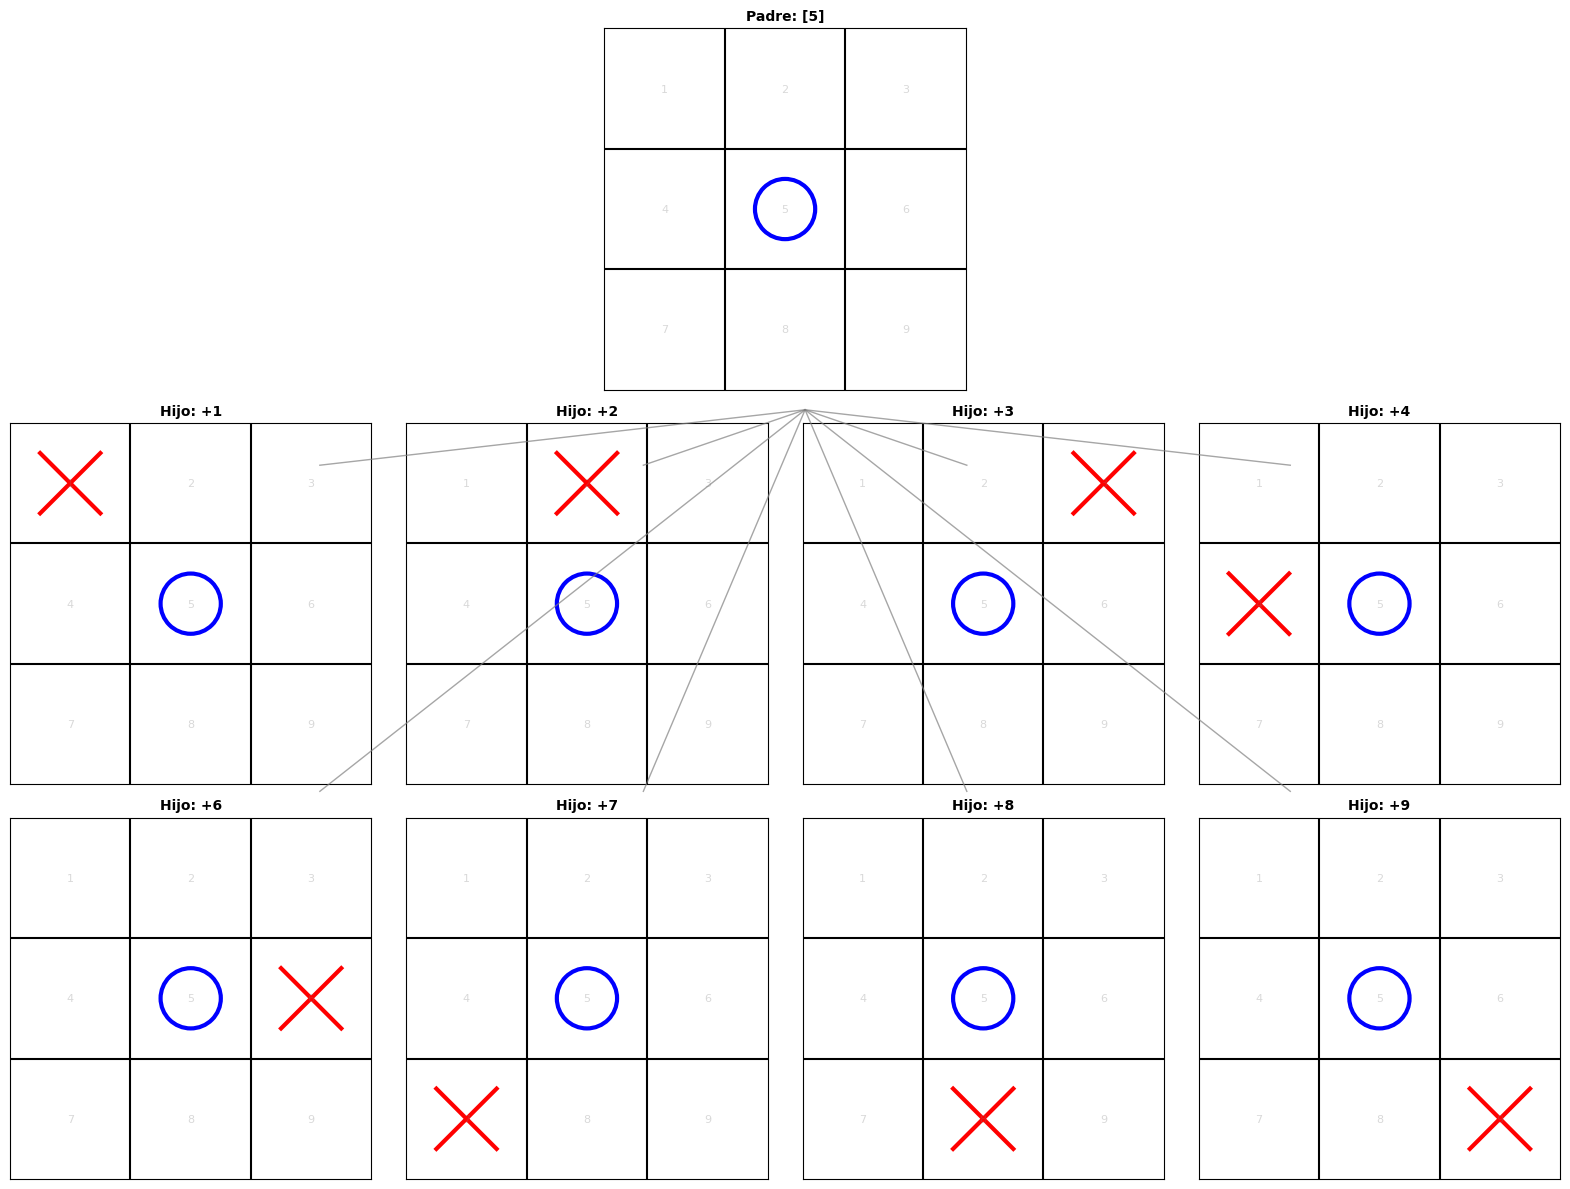


3. Árbol más complejo: Padre con X en posiciones 1 y 9


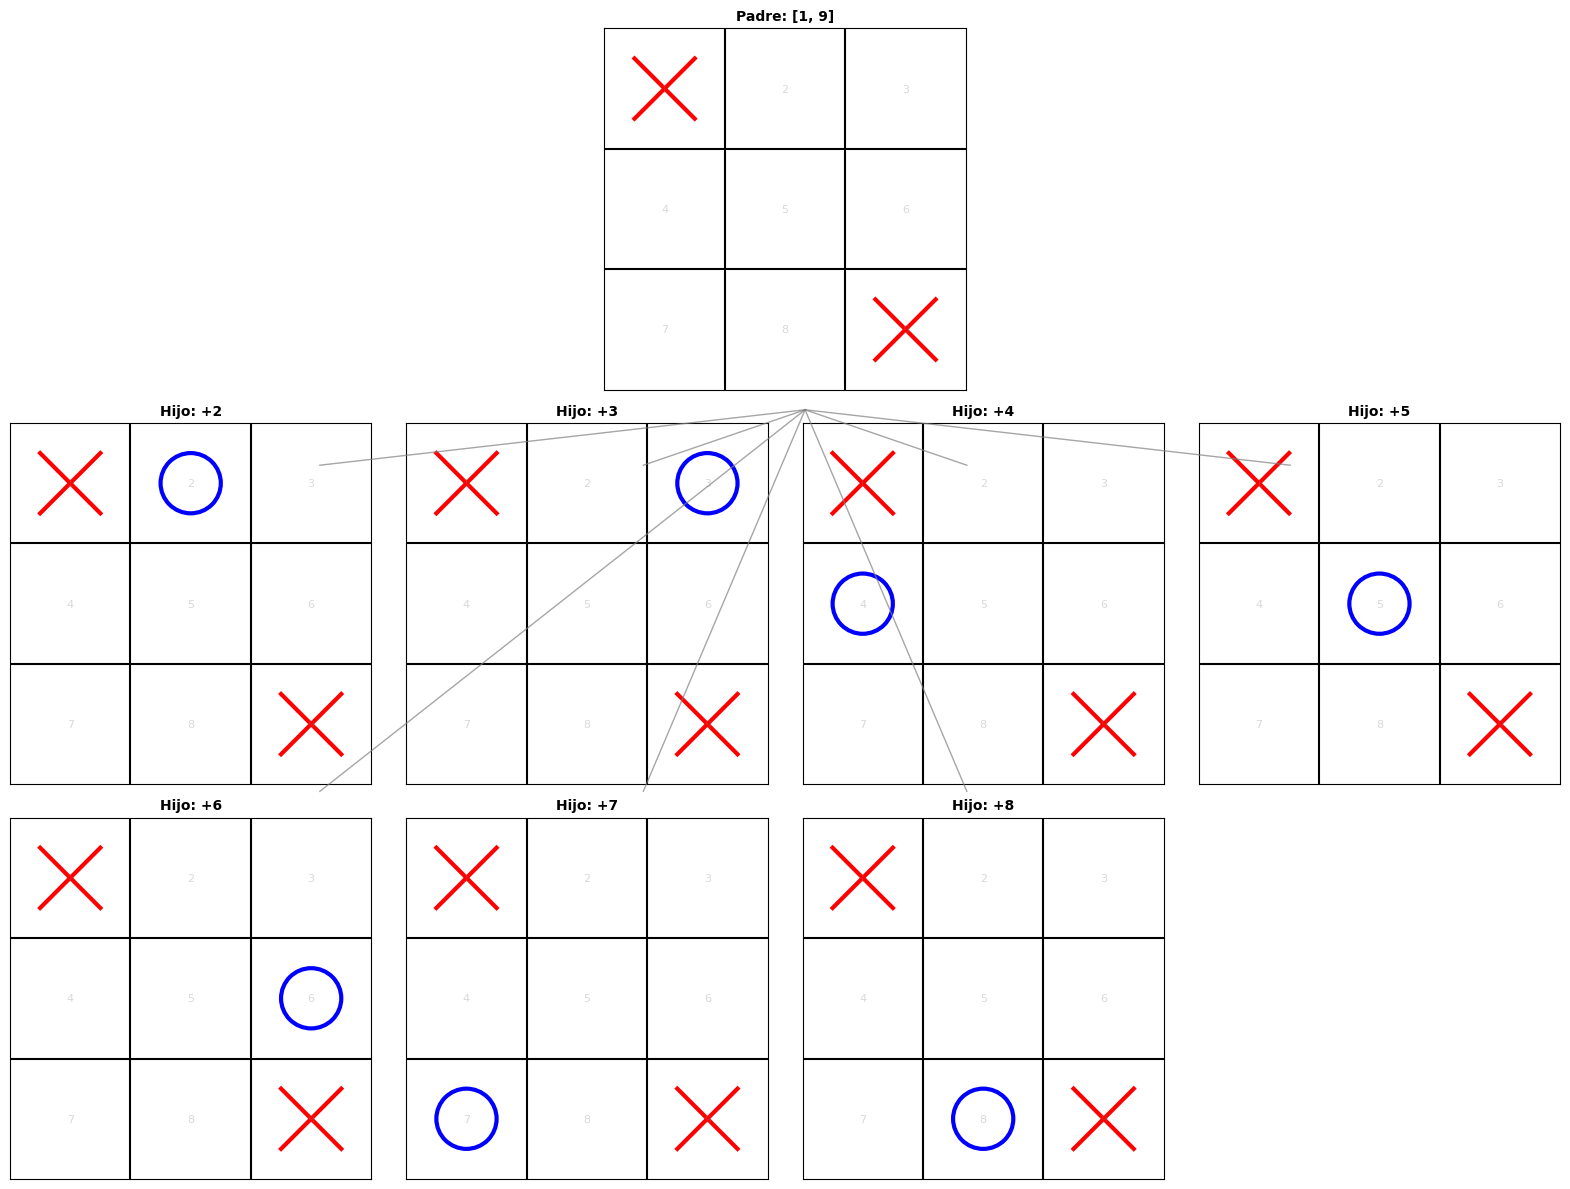


=== INSTRUCCIONES ===
Uso simple con etiquetas:
  triqui.graficar_triqui_simple(True, (-5, 10), '2+3=5', 1, 5, 9)

Generar árbol con etiquetas:
  triqui.generar_arbol_triqui([5], usar_x_padre=False,
                             alpha_beta_padre=(-10, 10),
                             valor_resultado_padre='Estado: 0')
  - Padre: O en posición 5
  - Hijos: X en cada posición libre EN UNA SOLA LÍNEA
  - Etiquetas automáticas para los hijos

Parámetros de etiquetas:
  - alpha_beta: tupla (alpha, beta) para mostrar arriba
  - valor_resultado: string para mostrar abajo


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

class TriquiInterface:
    def __init__(self):
        self.fig = None
        self.ax = None
        
    def setup_single_board(self, ax, title=""):
        """Configura un tablero individual del triqui"""
        ax.set_xlim(0, 3)
        ax.set_ylim(0, 3)
        ax.set_aspect('equal')
        
        # Título del tablero (si se proporciona)
        if title:
            ax.set_title(title, fontsize=10, fontweight='bold')
        
        # Eliminar ticks y labels
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Dibujar las líneas del tablero
        for i in range(1, 3):
            ax.axhline(y=i, color='black', linewidth=1.5)
            ax.axvline(x=i, color='black', linewidth=1.5)
        
        # Añadir números para referencia de posiciones (más pequeños)
        positions = [(0.5, 2.5, '1'), (1.5, 2.5, '2'), (2.5, 2.5, '3'),
                    (0.5, 1.5, '4'), (1.5, 1.5, '5'), (2.5, 1.5, '6'),
                    (0.5, 0.5, '7'), (1.5, 0.5, '8'), (2.5, 0.5, '9')]
        
        for x, y, num in positions:
            ax.text(x, y, num, ha='center', va='center', 
                   fontsize=8, alpha=0.3, color='gray')
    
    def agregar_etiquetas(self, ax, alpha_beta=None, valor_resultado=None):
        """Añade etiquetas arriba y abajo del tablero SIN interferir con él"""
        # Etiqueta superior (alpha, beta) - FUERA del área del tablero
        if alpha_beta:
            ax.text(1.5, 3.3, f"α={alpha_beta[0]}, β={alpha_beta[1]}", 
                   ha='center', va='center', fontsize=9, 
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8),
                   transform=ax.transData)
        
        # Etiqueta inferior (valor y resultado) - FUERA del área del tablero
        if valor_resultado:
            ax.text(1.5, -0.3, f"{valor_resultado}", 
                   ha='center', va='center', fontsize=9,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8),
                   transform=ax.transData)
    
    def draw_x(self, ax, x, y, size=0.25, color='red'):
        """Dibuja una X en la posición especificada"""
        line1_x = [x - size, x + size]
        line1_y = [y - size, y + size]
        line2_x = [x - size, x + size]
        line2_y = [y + size, y - size]
        
        ax.plot(line1_x, line1_y, color=color, linewidth=3)
        ax.plot(line2_x, line2_y, color=color, linewidth=3)
    
    def draw_o(self, ax, x, y, radius=0.25, color='blue'):
        """Dibuja un O (círculo) en la posición especificada"""
        circle = patches.Circle((x, y), radius, linewidth=3, 
                               edgecolor=color, facecolor='none')
        ax.add_patch(circle)
    
    def position_to_coords(self, pos):
        """Convierte número de posición (1-9) a coordenadas (x, y)"""
        pos_map = {
            1: (0.5, 2.5), 2: (1.5, 2.5), 3: (2.5, 2.5),
            4: (0.5, 1.5), 5: (1.5, 1.5), 6: (2.5, 1.5),
            7: (0.5, 0.5), 8: (1.5, 0.5), 9: (2.5, 0.5)
        }
        return pos_map.get(pos, None)
    
    def graficar_triqui_simple(self, usar_x=True, alpha_beta=None, valor_resultado=None, *posiciones):
        """
        Grafica un triqui simple con las posiciones especificadas
        
        Args:
            usar_x (bool): True para dibujar X, False para dibujar O
            alpha_beta (tuple): Tupla con valores (alpha, beta) para mostrar arriba
            valor_resultado (str): Texto para mostrar abajo del tablero
            *posiciones: números de posición (1-9)
        """
        self.fig, self.ax = plt.subplots(figsize=(6, 8))
        
        # Expandir límites del eje para acomodar etiquetas FUERA del tablero
        self.ax.set_xlim(-0.5, 3.5)
        self.ax.set_ylim(-0.8, 3.8)
        
        self.setup_single_board(self.ax, "Triqui")
        
        # Agregar etiquetas si se proporcionan
        if alpha_beta or valor_resultado:
            self.agregar_etiquetas(self.ax, alpha_beta, valor_resultado)
        
        # Dibujar las posiciones
        for pos in posiciones:
            if 1 <= pos <= 9:
                coords = self.position_to_coords(pos)
                if coords:
                    x, y = coords
                    if usar_x:
                        self.draw_x(self.ax, x, y)
                    else:
                        self.draw_o(self.ax, x, y)
        
        plt.tight_layout()
        return self.fig
    
    def generar_arbol_triqui(self, posiciones_padre, usar_x_padre=False):
        """
        Genera un árbol de triqui con un padre arriba y sus hijos abajo
        
        Args:
            posiciones_padre (list): Lista de posiciones ocupadas en el padre
            usar_x_padre (bool): Si el padre usa X o O
        """
        # Obtener posiciones disponibles para los hijos
        posiciones_ocupadas = set(posiciones_padre)
        posiciones_libres = [i for i in range(1, 10) if i not in posiciones_ocupadas]
        
        num_hijos = len(posiciones_libres)
        
        # Configurar la figura con el padre arriba y los hijos abajo
        if num_hijos == 0:
            print("No hay posiciones libres para generar hijos")
            return self.graficar_triqui_simple(usar_x_padre, *posiciones_padre)
        
        # Calcular dimensiones de la figura
        cols = min(4, num_hijos)  # Máximo 4 columnas
        rows_hijos = (num_hijos + cols - 1) // cols  # Filas necesarias para los hijos
        total_rows = 1 + rows_hijos  # 1 fila para el padre + filas para hijos
        
        fig = plt.figure(figsize=(4 * cols, 4 * total_rows))
        
        # Crear el tablero padre (centrado en la primera fila)
        ax_padre = plt.subplot2grid((total_rows, cols), (0, cols//2 - (1 if cols % 2 == 0 else 0)), 
                                   colspan=min(2, cols))
        self.setup_single_board(ax_padre, f"Padre: {posiciones_padre}")
        
        # Dibujar las piezas del padre
        for pos in posiciones_padre:
            coords = self.position_to_coords(pos)
            if coords:
                x, y = coords
                if usar_x_padre:
                    self.draw_x(ax_padre, x, y)
                else:
                    self.draw_o(ax_padre, x, y)
        
        # Crear los tableros hijos
        axes_hijos = []
        for i, pos_libre in enumerate(posiciones_libres):
            row = (i // cols) + 1  # +1 porque la fila 0 es para el padre
            col = i % cols
            
            ax_hijo = plt.subplot2grid((total_rows, cols), (row, col))
            titulo = f"Hijo: +{pos_libre}"
            self.setup_single_board(ax_hijo, titulo)
            
            # Dibujar las piezas del padre en el hijo
            for pos in posiciones_padre:
                coords = self.position_to_coords(pos)
                if coords:
                    x, y = coords
                    if usar_x_padre:
                        self.draw_x(ax_hijo, x, y)
                    else:
                        self.draw_o(ax_hijo, x, y)
            
            # Dibujar la nueva pieza (opuesta al padre)
            coords_nueva = self.position_to_coords(pos_libre)
            if coords_nueva:
                x, y = coords_nueva
                if not usar_x_padre:  # Si padre usa O, hijo usa X
                    self.draw_x(ax_hijo, x, y)
                else:  # Si padre usa X, hijo usa O
                    self.draw_o(ax_hijo, x, y)
            
            axes_hijos.append(ax_hijo)
        
        # Dibujar líneas conectoras del padre a los hijos
        for i, ax_hijo in enumerate(axes_hijos):
            # Obtener posiciones de los tableros en la figura
            padre_pos = ax_padre.get_position()
            hijo_pos = ax_hijo.get_position()
            
            # Coordenadas para la línea (del centro inferior del padre al centro superior del hijo)
            x1 = padre_pos.x0 + padre_pos.width / 2
            y1 = padre_pos.y0
            x2 = hijo_pos.x0 + hijo_pos.width / 2
            y2 = hijo_pos.y0 + hijo_pos.height
            
            # Dibujar la línea en coordenadas de la figura
            line = plt.Line2D([x1, x2], [y1, y2], transform=fig.transFigure, 
                             color='gray', linewidth=1, alpha=0.7)
            fig.lines.append(line)
        
        plt.tight_layout()
        self.fig = fig
        return fig
    
    def mostrar(self):
        """Muestra la interfaz"""
        if self.fig:
            plt.show()
        else:
            print("No hay figura para mostrar. Crea primero un triqui.")

# Función de conveniencia
def crear_triqui():
    """Crea y retorna una nueva instancia del triqui"""
    return TriquiInterface()

# Ejemplo de uso
if __name__ == "__main__":
    # Crear la interfaz
    triqui = crear_triqui()
    
    print("=== EJEMPLOS DE USO ===")
    
    print("\n1. Triqui simple con etiquetas:")
    triqui.graficar_triqui_simple(False, (-5, 10), "2 + 3 = 5", 5)  # O en posición 5 con etiquetas
    triqui.mostrar()
    
    print("\n2. Generando árbol: Padre con O en posición 5")
    print("   Los hijos tendrán X en cada posición libre (EN UNA SOLA LÍNEA)")
    triqui.generar_arbol_triqui([5], usar_x_padre=False, 
                            #    alpha_beta_padre=(-10, 10), 
                            #    valor_resultado_padre="Estado inicial = 0")
    )
    triqui.mostrar()
    
    print("\n3. Árbol más complejo: Padre con X en posiciones 1 y 9")
    triqui.generar_arbol_triqui([1, 9], usar_x_padre=True,
                            #    alpha_beta_padre=(-8, 5),
                            #    valor_resultado_padre="Jugadas: 2, Valor: 7")
    )
    triqui.mostrar()
    
    print("\n=== INSTRUCCIONES ===")
    print("Uso simple con etiquetas:")
    print("  triqui.graficar_triqui_simple(True, (-5, 10), '2+3=5', 1, 5, 9)")
    print("\nGenerar árbol con etiquetas:")
    print("  triqui.generar_arbol_triqui([5], usar_x_padre=False,")
    print("                             alpha_beta_padre=(-10, 10),")
    print("                             valor_resultado_padre='Estado: 0')")
    print("  - Padre: O en posición 5")
    print("  - Hijos: X en cada posición libre EN UNA SOLA LÍNEA")
    print("  - Etiquetas automáticas para los hijos")
    print("\nParámetros de etiquetas:")
    print("  - alpha_beta: tupla (alpha, beta) para mostrar arriba")
    print("  - valor_resultado: string para mostrar abajo")